<a href="https://colab.research.google.com/github/Amaan11205/PRACS/blob/main/assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original Dataset:
      Name  Maths  Science  English  Attendance
0   Amaan   85.0     88.0     90.0        95.0
1   Rahul   90.0     76.0     85.0        85.0
2   Sneha   78.0     85.0      NaN        80.0
3   Priya   92.0      NaN     88.0        90.0
4   Arjun   88.0     90.0     92.0         NaN
5   Kiran    NaN     89.0     87.0        88.0
6    Neha   95.0     94.0     96.0        92.0
7   Rohit   60.0     65.0     70.0        60.0
8  Simran   72.0     70.0     75.0        70.0
9   Ankit  110.0     80.0     82.0       105.0

Missing Values:
 Name          0
Maths         1
Science       1
English       1
Attendance    1
dtype: int64

After Cleaning:
      Name       Maths    Science  English  Attendance
0   Amaan   85.000000  88.000000     90.0        95.0
1   Rahul   90.000000  76.000000     85.0        85.0
2   Sneha   78.000000  85.000000     85.0        80.0
3   Priya   92.000000  81.888889     88.0        90.0
4   Arjun   88.000000  90.000000     92.0        85.0
5   Kiran  

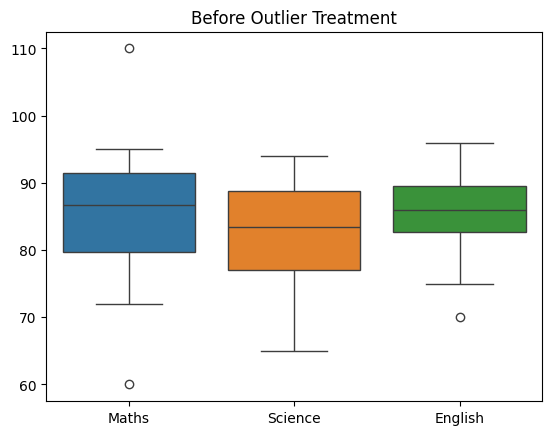

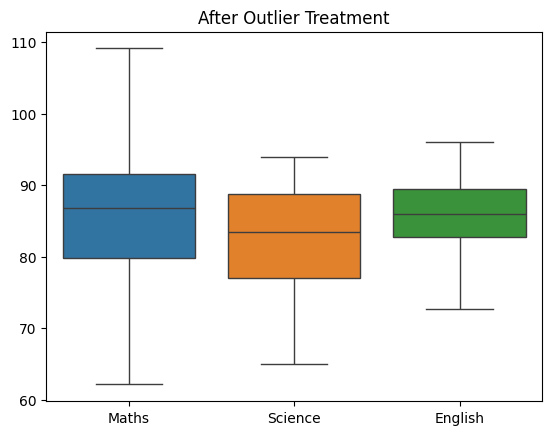

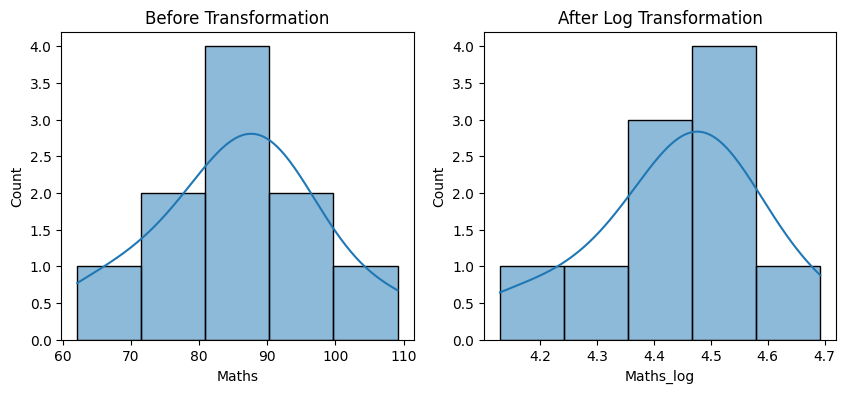


Final Dataset:
      Name       Maths    Science  English  Attendance  Maths_log
0   Amaan   85.000000  88.000000   90.000        95.0   4.442651
1   Rahul   90.000000  76.000000   85.000        85.0   4.499810
2   Sneha   78.000000  85.000000   85.000        80.0   4.356709
3   Priya   92.000000  81.888889   88.000        90.0   4.521789
4   Arjun   88.000000  90.000000   92.000        85.0   4.477337
5   Kiran   85.555556  89.000000   87.000        88.0   4.449166
6    Neha   95.000000  94.000000   96.000        92.0   4.553877
7   Rohit   62.125000  65.000000   72.625        60.0   4.129148
8  Simran   72.000000  70.000000   75.000        70.0   4.276666
9   Ankit  109.125000  80.000000   82.000       100.0   4.692494


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------
# Create Academic Performance Dataset
# --------------------------------------
data = {
    'Name': ['Amaan','Rahul','Sneha','Priya','Arjun','Kiran','Neha','Rohit','Simran','Ankit'],
    'Maths': [85, 90, 78, 92, 88, None, 95, 60, 72, 110],   # Missing + outlier
    'Science': [88, 76, 85, None, 90, 89, 94, 65, 70, 80],
    'English': [90, 85, None, 88, 92, 87, 96, 70, 75, 82],
    'Attendance': [95, 85, 80, 90, None, 88, 92, 60, 70, 105]  # >100 inconsistency
}

df = pd.DataFrame(data)

print("Original Dataset:\n", df)

# --------------------------------------
# 1. Missing Values & Inconsistencies
# --------------------------------------
print("\nMissing Values:\n", df.isnull().sum())

# Fill missing values with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# Fix inconsistency (Attendance > 100)
df['Attendance'] = np.where(df['Attendance'] > 100, 100, df['Attendance'])

print("\nAfter Cleaning:\n", df)

# --------------------------------------
# 2. Outlier Detection & Treatment
# --------------------------------------
# Boxplot before
sns.boxplot(data=df[['Maths','Science','English']])
plt.title("Before Outlier Treatment")
plt.show()

# IQR Method
Q1 = df[['Maths','Science','English']].quantile(0.25)
Q3 = df[['Maths','Science','English']].quantile(0.75)
IQR = Q3 - Q1

df[['Maths','Science','English']] = df[['Maths','Science','English']].clip(
    Q1 - 1.5*IQR, Q3 + 1.5*IQR, axis=1
)

# Boxplot after
sns.boxplot(data=df[['Maths','Science','English']])
plt.title("After Outlier Treatment")
plt.show()

# --------------------------------------
# 3. Data Transformation
# --------------------------------------
# Log transformation to reduce skewness
df['Maths_log'] = np.log(df['Maths'])

# Compare before & after
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df['Maths'], kde=True)
plt.title("Before Transformation")

plt.subplot(1,2,2)
sns.histplot(df['Maths_log'], kde=True)
plt.title("After Log Transformation")

plt.show()

print("\nFinal Dataset:\n", df)